In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('./nba_2017_nba_players_with_salary.csv')
data.shape

(342, 39)

In [3]:
data.describe()

,Unnamed: 0,Rk,AGE,MP,FG,FGA,FG%,3P,3PA,3P%,...,GP,MPG,ORPM,DRPM,RPM,WINS_RPM,PIE,PACE,W,SALARY_MILLIONS
count,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,320.000000,...,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000
mean,170.500000,217.269006,26.444444,21.572515,3.483626,7.725439,0.446096,0.865789,2.440058,0.307016,...,58.198830,21.572807,-0.676023,-0.005789,-0.681813,2.861725,9.186842,98.341053,28.950292,7.294006
std,98.871128,136.403138,4.295686,8.804018,2.200872,4.646933,0.078992,0.780010,2.021716,0.134691,...,22.282015,8.804121,2.063237,1.614293,2.522014,3.880914,3.585475,2.870091,14.603876,6.516326
min,0.000000,1.000000,19.000000,2.200000,0.000000,0.800000,0.000000,0.000000,0.000000,0.000000,...,2.000000,2.200000,-4.430000,-3.920000,-6.600000,-2.320000,-1.600000,87.460000,0.000000,0.030000
25%,85.250000,100.250000,23.000000,15.025000,1.800000,4.225000,0.402250,0.200000,0.800000,0.280250,...,43.500000,15.025000,-2.147500,-1.222500,-2.422500,0.102500,7.100000,96.850000,19.000000,2.185000
50%,170.500000,205.500000,26.000000,21.650000,3.000000,6.700000,0.442000,0.700000,2.200000,0.340500,...,66.000000,21.650000,-0.990000,-0.130000,-1.170000,1.410000,8.700000,98.205000,29.000000,4.920000
75%,255.750000,327.750000,29.000000,29.075000,4.700000,10.400000,0.481000,1.400000,3.600000,0.373500,...,76.000000,29.075000,0.257500,1.067500,0.865000,4.487500,10.900000,100.060000,39.000000,11.110000
max,341.000000,482.000000,40.000000,37.800000,10.300000,24.000000,0.750000,4.100000,10.000000,1.000000,...,82.000000,37.800000,7.270000,6.020000,8.420000,20.430000,23.000000,109.870000,66.000000,30.960000


In [4]:
#效率值相关性分析
dat_cor = data.loc[:,['RPM','AGE','SALARY_MILLIONS','ORB','TRB','AST','STL','BLK','TOV','PF','POINTS','GP','MPG','ORPM','DRPM']]
dat_cor.shape

(342, 15)

In [5]:
#获取数据之间的相关性
corr = dat_cor.corr()
corr

,RPM,AGE,SALARY_MILLIONS,ORB,TRB,AST,STL,BLK,TOV,PF,POINTS,GP,MPG,ORPM,DRPM
RPM,1.000000,0.175820,0.477542,0.388764,0.587853,0.481971,0.599008,0.463097,0.492014,0.434226,0.604432,0.340810,0.549449,0.769822,0.578388
AGE,0.175820,1.000000,0.353312,-0.015752,0.062064,0.114908,0.069892,-0.062917,0.030673,0.005512,0.031422,0.051863,0.099657,0.136177,0.100636
SALARY_MILLIONS,0.477542,0.353312,1.000000,0.264954,0.482088,0.486159,0.446763,0.260288,0.536993,0.341512,0.635425,0.348093,0.594162,0.503682,0.102307
ORB,0.388764,-0.015752,0.264954,1.000000,0.861103,-0.011632,0.169075,0.654265,0.274670,0.557957,0.284908,0.296975,0.342140,0.102113,0.476857
TRB,0.587853,0.062064,0.482088,0.861103,1.000000,0.257379,0.415318,0.698947,0.531124,0.675389,0.573219,0.446355,0.618587,0.352018,0.468489
AST,0.481971,0.114908,0.486159,-0.011632,0.257379,1.000000,0.683438,0.050367,0.839331,0.323374,0.678980,0.334944,0.640273,0.673077,-0.107280
STL,0.599008,0.069892,0.446763,0.169075,0.415318,0.683438,1.000000,0.257638,0.669642,0.509130,0.653695,0.441132,0.749596,0.593146,0.177728
BLK,0.463097,-0.062917,0.260288,0.654265,0.698947,0.050367,0.257638,1.000000,0.310396,0.601185,0.352639,0.314585,0.387176,0.138512,0.546464
TOV,0.492014,0.030673,0.536993,0.274670,0.531124,0.839331,0.669642,0.310396,1.000000,0.566313,0.834074,0.398315,0.743525,0.621213,-0.025302
PF,0.434226,0.005512,0.341512,0.557957,0.675389,0.323374,0.509130,0.601185,0.566313,1.000000,0.533770,0.522945,0.668645,0.288196,0.310046


<Axes: >

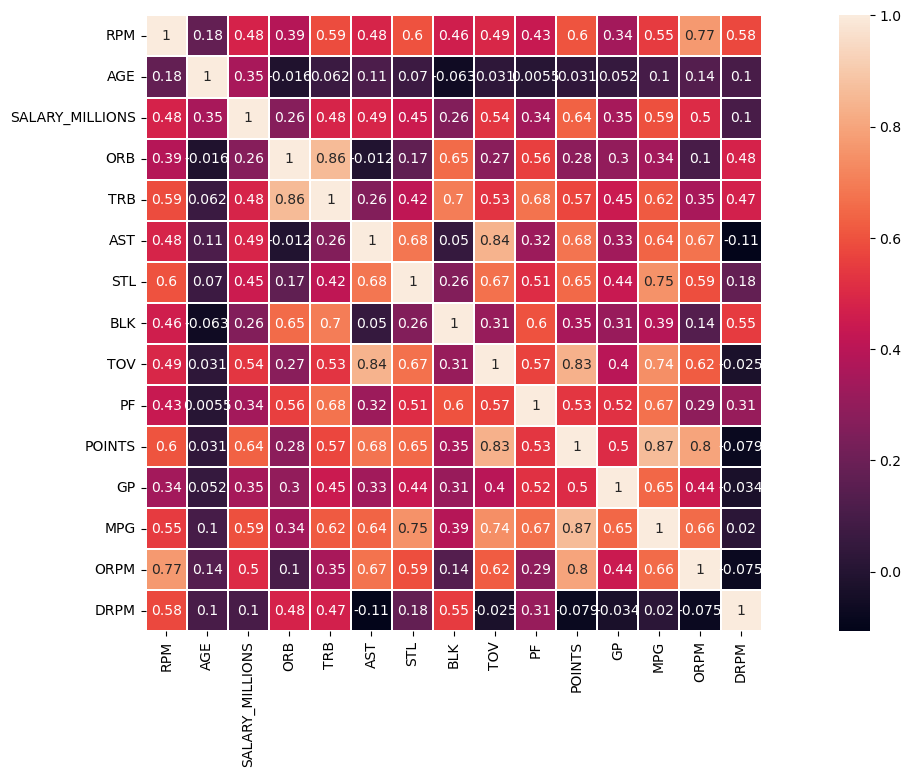

In [6]:
plt.figure(figsize=(20,8),dpi=100)
sns.heatmap(corr,square=True,linewidths=0.1,annot=True)

基本分析

In [7]:
#薪资最高的球员
data.loc[:,['PLAYER','RPM','SALARY_MILLIONS','AGE','MPG']].sort_values(by='SALARY_MILLIONS',ascending=False)

,PLAYER,RPM,SALARY_MILLIONS,AGE,MPG
6,LeBron James,8.42,30.96,32,37.8
25,Mike Conley,4.47,26.54,29,33.2
67,Al Horford,1.82,26.54,30,32.3
0,Russell Westbrook,6.27,26.50,28,34.6
1,James Harden,4.81,26.50,27,36.4
...,...,...,...,...,...
280,Anthony Brown,-1.76,0.06,24,14.5
264,Jarell Eddie,-1.69,0.06,25,12.4
299,Jarrett Jack,-1.84,0.06,33,16.5
339,Alonzo Gee,-1.68,0.06,29,6.8


In [8]:
#效率值最高的球员
data.loc[:,['PLAYER','RPM','SALARY_MILLIONS','AGE','MPG']].sort_values(by='RPM',ascending=False)

,PLAYER,RPM,SALARY_MILLIONS,AGE,MPG
6,LeBron James,8.42,30.96,32,37.8
37,Chris Paul,7.92,22.87,31,31.5
8,Stephen Curry,7.41,12.11,28,33.4
120,Draymond Green,7.14,15.33,26,32.5
7,Kawhi Leonard,7.08,17.64,25,33.4
...,...,...,...,...,...
207,Marcus Thornton,-4.95,0.98,29,17.4
257,Trey Burke,-5.24,3.39,24,12.3
101,Brandon Knight,-5.32,12.61,25,21.1
92,Jahlil Okafor,-5.69,4.79,21,22.7


In [9]:
#出场时间最高的球员
data.loc[:,['PLAYER','RPM','SALARY_MILLIONS','AGE','MPG']].sort_values(by='MPG',ascending=False)

,PLAYER,RPM,SALARY_MILLIONS,AGE,MPG
6,LeBron James,8.42,30.96,32,37.8
32,Zach LaVine,-2.97,2.24,21,37.2
14,Andrew Wiggins,-1.60,6.01,21,37.2
11,Karl-Anthony Towns,2.13,5.96,21,37.0
12,Jimmy Butler,6.62,17.55,27,37.0
...,...,...,...,...,...
336,Diamond Stone,-2.28,1.31,19,3.4
323,Demetrius Jackson,-2.07,1.38,22,3.4
341,Aaron Harrison,-1.74,0.87,22,3.4
337,Brice Johnson,-1.24,1.33,22,3.0


单变量分析

C:\Users\86157\AppData\Local\Temp\ipykernel_36632\3447862977.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['SALARY_MILLIONS'])
C:\Users\86157\AppData\Local\Temp\ipykernel_36632\3447862977.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['RPM'])
C:\Users\86157\AppData\Local\Tem

Text(0, 0.5, 'AGE')

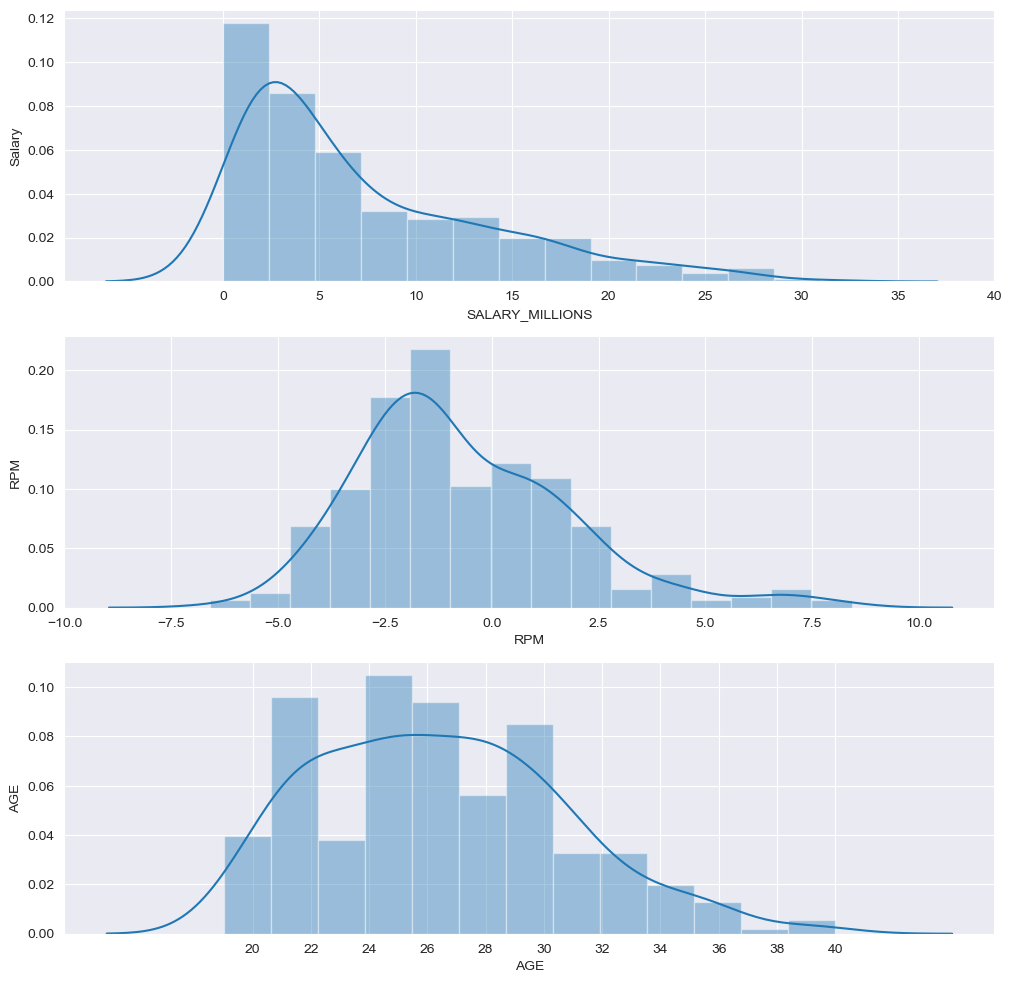

In [10]:
sns.set_style('darkgrid')
plt.figure(figsize=(12,12),dpi=100)
plt.subplot(3,1,1)
sns.distplot(data['SALARY_MILLIONS'])
plt.xticks(np.linspace(0,40,9))
plt.ylabel('Salary',size=10)

plt.subplot(3,1,2)
sns.distplot(data['RPM'])
plt.xticks(np.linspace(-10,10,9))
plt.ylabel('RPM',size=10)

plt.subplot(3,1,3)
sns.distplot(data['AGE'])
plt.xticks(np.linspace(20,40,11))
plt.ylabel('AGE',size=10)

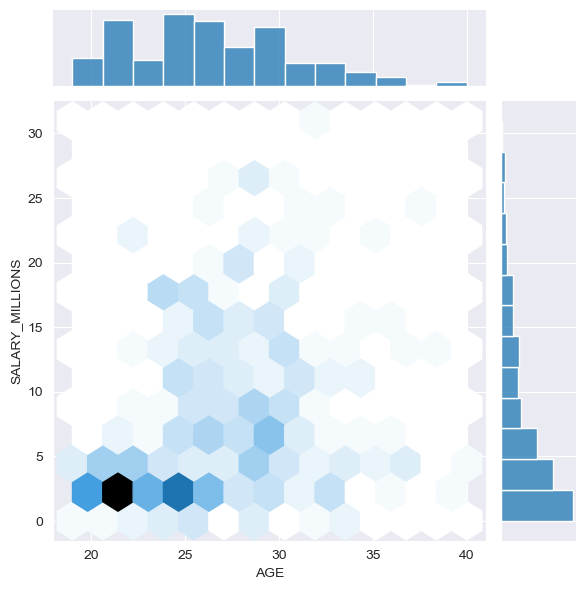

In [11]:
#双变量分析
sns.jointplot(x=data.AGE,y=data.SALARY_MILLIONS,kind='hex')

In [12]:
#多变量分析
multi_data=data.loc[:,['RPM','SALARY_MILLIONS','AGE','POINTS']]
multi_data

,RPM,SALARY_MILLIONS,AGE,POINTS
0,6.27,26.50,28,31.6
1,4.81,26.50,27,29.1
2,1.83,6.59,27,28.9
3,4.35,22.12,23,28.0
4,4.20,16.96,26,27.0
...,...,...,...,...
337,-1.24,1.33,22,1.3
338,-0.92,0.07,22,1.0
339,-1.68,0.06,29,0.8
340,-1.91,0.98,34,0.4


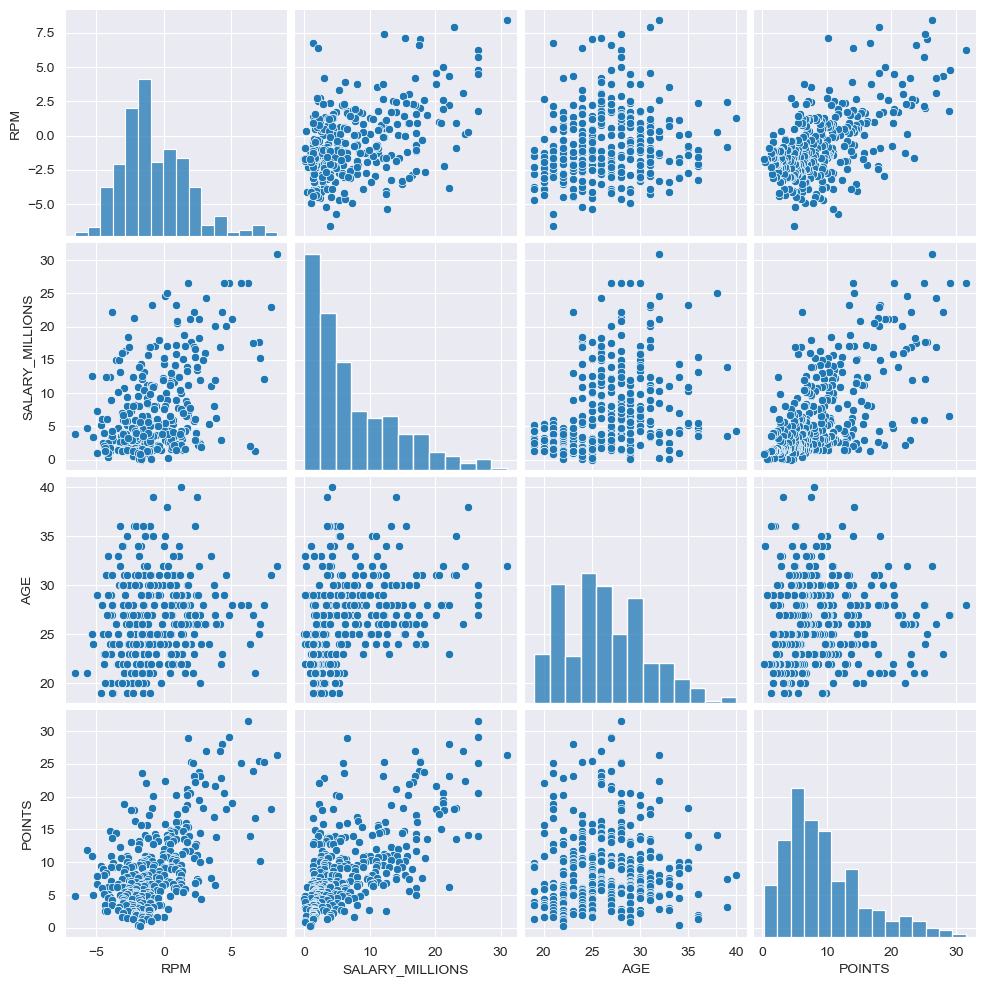

In [13]:
sns.pairplot(multi_data)

In [17]:
def age_cut(df):
    '''年龄划分'''
    if df.AGE <= 24:
        return 'young'
    elif df.AGE >= 30:
        return 'old'
    else:
        return 'best'

In [18]:
data['age_cut']=data.apply(lambda x:age_cut(x),axis=1)

In [19]:
data

,Unnamed: 0,Rk,PLAYER,POSITION,AGE,MP,FG,FGA,FG%,3P,...,MPG,ORPM,DRPM,RPM,WINS_RPM,PIE,PACE,W,SALARY_MILLIONS,age_cut
0,0,1,Russell Westbrook,PG,28,34.6,10.2,24.0,0.425,2.5,...,34.6,6.74,-0.47,6.27,17.34,23.0,102.31,46,26.50,best
1,1,2,James Harden,PG,27,36.4,8.3,18.9,0.440,3.2,...,36.4,6.38,-1.57,4.81,15.54,19.0,102.98,54,26.50,best
2,2,3,Isaiah Thomas,PG,27,33.8,9.0,19.4,0.463,3.2,...,33.8,5.72,-3.89,1.83,8.19,16.1,99.84,51,6.59,best
3,3,4,Anthony Davis,C,23,36.1,10.3,20.3,0.505,0.5,...,36.1,0.45,3.90,4.35,12.81,19.2,100.19,31,22.12,young
4,4,6,DeMarcus Cousins,C,26,34.2,9.0,19.9,0.452,1.8,...,34.2,3.56,0.64,4.20,11.26,17.8,97.11,30,16.96,best
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,337,466,Brice Johnson,PF,22,3.0,0.7,2.3,0.286,0.0,...,3.0,-2.32,1.08,-1.24,0.01,10.8,95.72,1,1.33,young
338,338,471,Mike Tobey,C,22,12.5,0.5,2.0,0.250,0.0,...,12.5,-1.91,0.99,-0.92,0.03,-1.6,91.41,0,0.07,young
339,339,475,Alonzo Gee,SF,29,6.8,0.2,1.1,0.214,0.0,...,6.8,-2.11,0.43,-1.68,0.08,0.8,104.33,4,0.06,best
340,340,481,John Lucas III,PG,34,2.2,0.2,0.8,0.250,0.0,...,2.2,-1.30,-0.61,-1.91,0.01,7.3,94.47,3,0.98,old


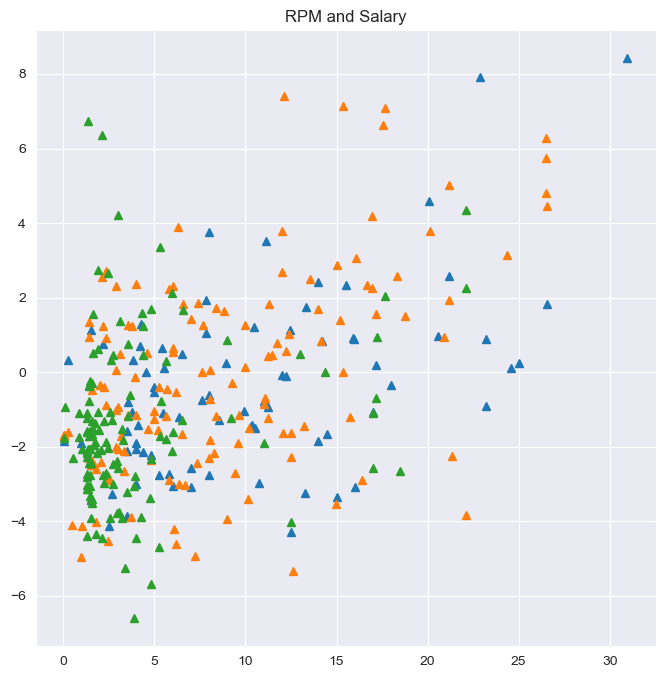

In [23]:
#通过年龄段对球员薪水和效率进行分析
sns.set_style('darkgrid')
plt.figure(figsize=(8,8),dpi=100)
plt.title('RPM and Salary')
x1 = data.loc[data.age_cut == 'old'].SALARY_MILLIONS
y1 = data.loc[data.age_cut == 'old'].RPM
plt.plot(x1,y1,'^')
x2 = data.loc[data.age_cut == 'best'].SALARY_MILLIONS
y2 = data.loc[data.age_cut == 'best'].RPM
plt.plot(x2,y2,'^')
x3 = data.loc[data.age_cut == 'young'].SALARY_MILLIONS
y3 = data.loc[data.age_cut == 'young'].RPM
plt.plot(x3,y3,'^')

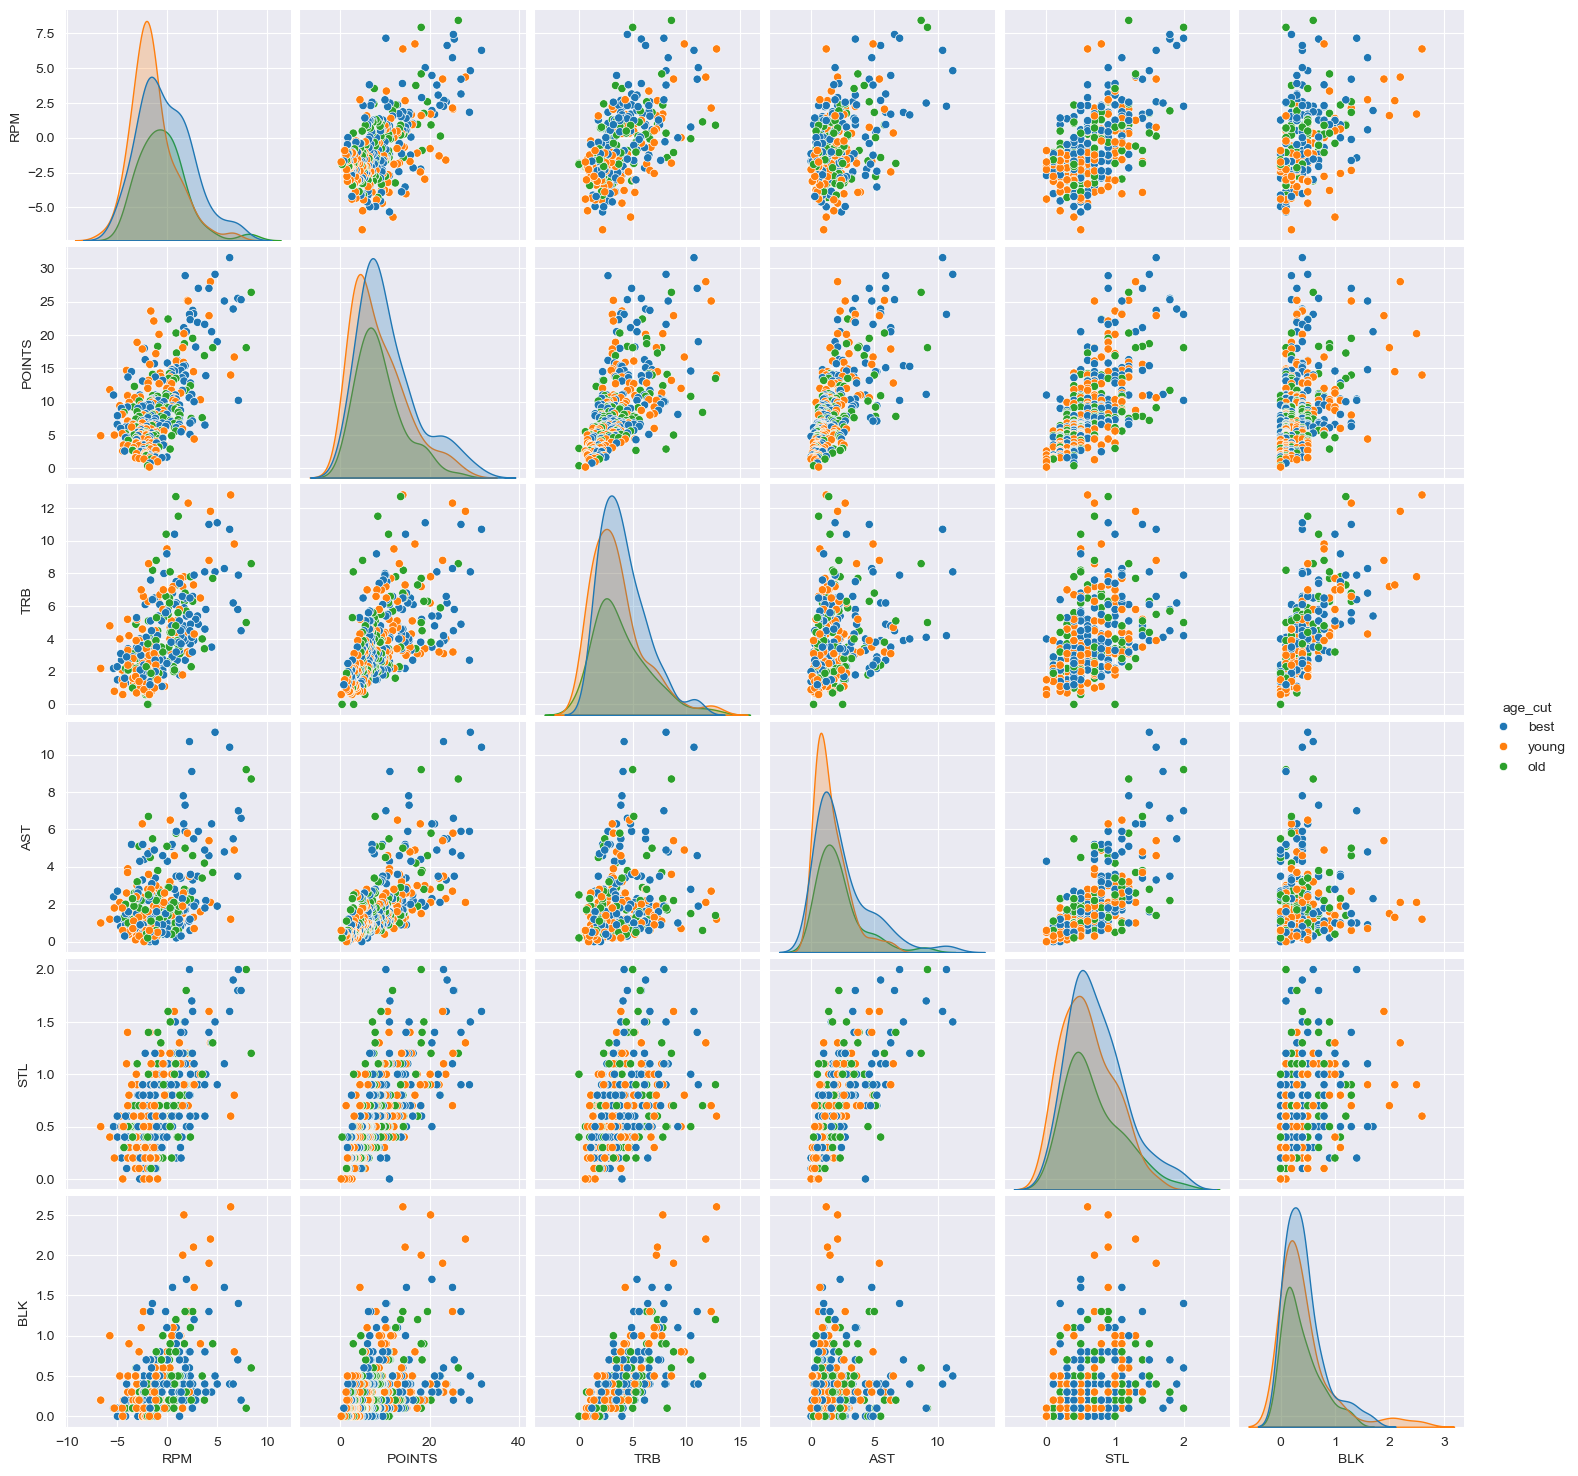

In [28]:
multi_data2 = data.loc[:,['RPM','POINTS','TRB','AST','STL','BLK','age_cut']]
sns.pairplot(multi_data2,hue='age_cut')